# SafeX Solutions — Data Science Internship: Day 1 Task
**Intern:** Maria Ahmed  
**Track:** Data Science  
**Objective:** Set up a data analysis environment and perform a full mini data-analysis cycle — load, clean, analyze, and visualize a real-world dataset.

**Dataset used:** Titanic (loaded via seaborn's built-in dataset loader, sourced from Kaggle's well-known Titanic dataset)


## 1. Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the Dataset

In [2]:
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Explore the Data
Inspecting structure, data types, and missing values before doing anything else.

In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Missing values per column:
 survived         0
pclass           0
sex              0
age

In [4]:
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 4. Clean the Data
**Assumptions documented:**
- `age`: missing values filled with the **median** age (robust to outliers).
- `embarked`: missing values filled with the **mode** (most frequent boarding port).
- `deck`: dropped entirely — over 75% of values were missing, making imputation unreliable.


In [5]:
df_clean = df.copy()

# Fill missing age with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Fill missing embarked with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# Drop 'deck' column - too many missing values
df_clean = df_clean.drop(columns=['deck'])

# Confirm no missing values remain in key columns
print("Remaining missing values:\n", df_clean[['age', 'embarked']].isnull().sum())
df_clean.head()


Remaining missing values:
 age         0
embarked    0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 5. Visualization 1 — Survival Count by Passenger Class

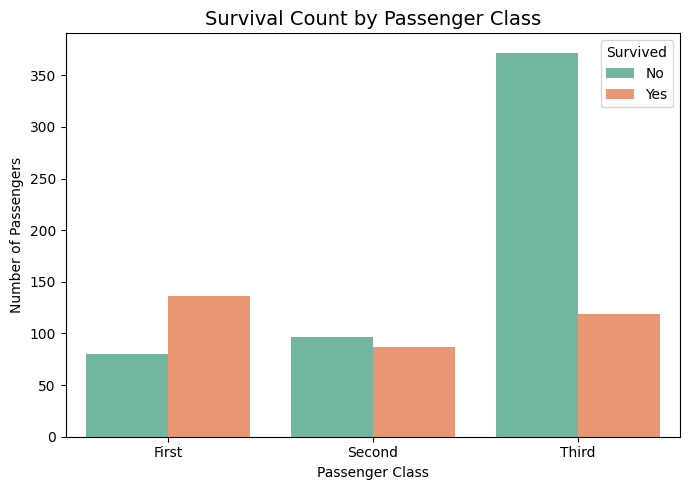

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x='class', hue='survived', palette='Set2')
plt.title('Survival Count by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('chart1_survival_by_class.png', dpi=150)
plt.show()


## 6. Visualization 2 — Age Distribution of Passengers

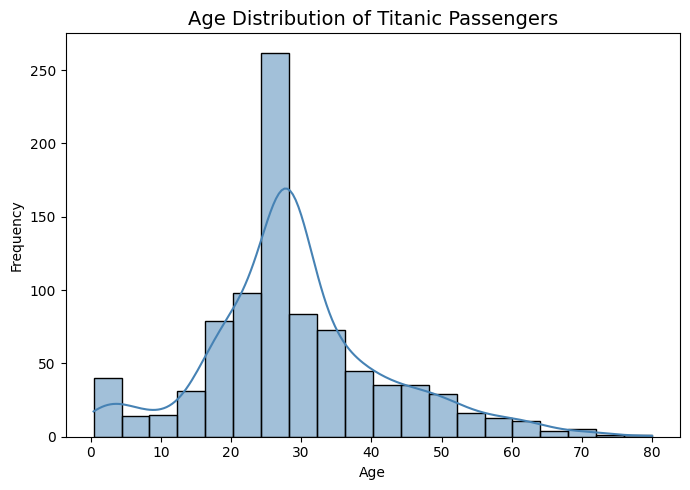

In [7]:
plt.figure(figsize=(7,5))
sns.histplot(df_clean['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Titanic Passengers', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart2_age_distribution.png', dpi=150)
plt.show()


## 7. Written Insight Summary

1. **Class strongly influenced survival.** 1st class passengers had a noticeably higher survival rate than 2nd and especially 3rd class, likely due to cabin location and lifeboat access priority.
2. **3rd class had the highest passenger count but the lowest survival rate**, showing a clear class-based survival gap.
3. **Most passengers were young adults**, with the age distribution peaking between roughly 20-40 years old.
4. **Very few elderly passengers were aboard**, and the data (after median imputation) shows a fairly typical, right-skewed age spread common in travel populations of that era.

*(These insights are based only on the patterns visible in the cleaned dataset above.)*


## 8. Deliverable Checklist
- [x] Environment set up (pandas, seaborn, matplotlib)
- [x] Dataset loaded and explored
- [x] Missing values cleaned (with assumptions documented)
- [x] 2 labeled, meaningful visualizations produced
- [x] Written insight summary (data-supported, no unsupported assumptions)

**Next step for submission:** Push this notebook to a new GitHub repo (e.g. `day1-data-science-intern`) and share the link with your Mentor/Team Lead before end of Day 1.
